
# Online Retail: przygotowanie danych do analizy ML w Polars

Pierwsza część notebooka przygotowuje tabelę cech klientów:

> **jeden klient = jeden rekord**

Przepływ:

```text
surowe pozycje zamówień
→ ujednolicenie kolumn i typów
→ kontrola jakości
→ rozdzielenie sprzedaży oraz zwrotów
→ agregacje klienta
→ cechy RFM i dodatkowe wskaźniki
→ zapis tabeli cech do Parquet
```

Notebook obsługuje popularne warianty kolumn zbiorów **Online Retail** i **Online Retail II**, m.in.:

- `InvoiceNo` lub `Invoice`,
- `UnitPrice` lub `Price`,
- `CustomerID` lub `Customer ID`.

## Import danych
1. Pobierz plik online_retail_II.csv ze strony https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci?resource=download
2. Umieść plik online_retail_II.csv w katalogu `data/`.


## Instalacja i import bibliotek

In [28]:
%pip install -U polars pyarrow matplotlib fastexcel scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [29]:
from __future__ import annotations

from datetime import timedelta
from pathlib import Path
import re
import polars as pl

print("Polars:", pl.__version__)

Polars: 1.42.1



## 1. Konfiguracja źródła danych

`scan_csv()` i `scan_parquet()` zwracają `LazyFrame`. Operacje są zapisywane jako plan zapytania, a wykonanie następuje dopiero po wywołaniu `collect()` albo zapisie wyniku.


### Konwersja CSV do Parquet

Excel nie jest formatem odpowiednim do leniwego skanowania, dlatego warto przekonwertować go raz do Parquet.
Dla pliku Online Retail II zawierającego kilka arkuszy należy wczytać arkusze osobno, połączyć je i zapisać jako jeden plik.


In [30]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = Path("data/online_retail_II.csv")
DATA_PATH = Path("data/online_retail.parquet")

df_csv = pl.read_csv(
    CSV_PATH,
    schema_overrides={
        "Invoice": pl.String,
    },
)

df_csv.write_parquet(DATA_PATH)


## 2. Leniwe wczytanie danych

Nie wywołujemy jeszcze `collect()`. Na tym etapie budujemy jedynie początek planu przetwarzania.


In [31]:
raw_lf = pl.scan_parquet(DATA_PATH)
raw_lf.collect_schema()

Schema([('Invoice', String),
        ('StockCode', String),
        ('Description', String),
        ('Quantity', Int64),
        ('InvoiceDate', String),
        ('Price', Float64),
        ('Customer ID', Float64),
        ('Country', String)])

## 3. Ujednolicenie nazw kolumn

Funkcja poniżej mapuje nazwy kolumn na jeden spójny format.

In [32]:
COLUMN_ALIASES: dict[str, str] = {
    "invoice_no": "invoice",
    "stock_code": "stockcode",
    "description": "description",
    "quantity": "quantity",
    "invoice_date": "invoicedate",
    "unit_price": "price",
    "customer_id": "customerid",
    "country": "country",
}

def normalized_name(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", name.lower())

def canonicalize_columns(lf: pl.LazyFrame) -> pl.LazyFrame:
    source_columns = lf.collect_schema().names()
    lookup = {normalized_name(column): column for column in source_columns}

    rename_map: dict[str, str] = {}

    for target, alias in COLUMN_ALIASES.items():
        if alias in lookup:
            rename_map[lookup[alias]] = target

    lf = lf.rename(rename_map)

    return  lf


canonical_lf = canonicalize_columns(raw_lf)
canonical_lf.collect_schema()


Schema([('invoice_no', String),
        ('stock_code', String),
        ('description', String),
        ('quantity', Int64),
        ('invoice_date', String),
        ('unit_price', Float64),
        ('customer_id', Float64),
        ('country', String)])


## 4. Typy danych i flagi jakości

Przed filtrowaniem tworzymy flagi:

- `is_cancelled` — numer faktury zaczyna się od `C`,
- `is_return` — anulowanie albo ujemna ilość,
- `line_revenue` — wartość pozycji.

Informację o zwrotach zachowujemy **przed usunięciem anulowanych pozycji**, ponieważ później wykorzystamy ją do obliczenia `return_rate`.


In [33]:
typed_lf = (
    canonical_lf
    .with_columns(
        pl.col("invoice_no").cast(pl.String, strict=False).str.strip_chars(),
        pl.col("stock_code").cast(pl.String, strict=False).str.strip_chars(),
        pl.col("description").cast(pl.String, strict=False).str.strip_chars(),
        pl.col("quantity").cast(pl.Float64, strict=False),
        pl.col("unit_price").cast(pl.Float64, strict=False),
        pl.col("invoice_date")
        .cast(pl.String, strict=False)
        .str.to_datetime(strict=False),
        pl.col("customer_id")
        .cast(pl.Float64, strict=False)
        .cast(pl.Int64, strict=False)
        .cast(pl.String, strict=False),
        pl.col("country").cast(pl.String, strict=False).str.strip_chars(),
    )
    .with_columns(
        pl.col("invoice_no")
        .str.to_uppercase()
        .str.starts_with("C")
        .fill_null(False)
        .alias("is_cancelled"),
    )
    .with_columns(
        (
            pl.col("is_cancelled")
            | (pl.col("quantity").fill_null(0) < 0)
        ).alias("is_return"),
        (
            pl.col("quantity") * pl.col("unit_price")
        ).alias("line_revenue"),
    )
)

typed_lf.select(
    "invoice_no",
    "customer_id",
    "invoice_date",
    "quantity",
    "unit_price",
    "is_cancelled",
    "is_return",
    "line_revenue",
).head(10).collect()


invoice_no,customer_id,invoice_date,quantity,unit_price,is_cancelled,is_return,line_revenue
str,str,datetime[μs],f64,f64,bool,bool,f64
"""489434""","""13085""",2009-12-01 07:45:00,12.0,6.95,false,false,83.4
"""489434""","""13085""",2009-12-01 07:45:00,12.0,6.75,false,false,81.0
"""489434""","""13085""",2009-12-01 07:45:00,12.0,6.75,false,false,81.0
"""489434""","""13085""",2009-12-01 07:45:00,48.0,2.1,false,false,100.8
"""489434""","""13085""",2009-12-01 07:45:00,24.0,1.25,false,false,30.0
"""489434""","""13085""",2009-12-01 07:45:00,24.0,1.65,false,false,39.6
"""489434""","""13085""",2009-12-01 07:45:00,24.0,1.25,false,false,30.0
"""489434""","""13085""",2009-12-01 07:45:00,10.0,5.95,false,false,59.5
"""489435""","""13085""",2009-12-01 07:46:00,12.0,2.55,false,false,30.6



## 5. Kontrola jakości danych

Zanim usuniemy rekordy, sprawdzamy skalę problemów. W prawdziwej analizie warto zapisać taki raport jako artefakt procesu.


In [34]:
quality_report = typed_lf.select(
    pl.len().alias("rows_total"),
    pl.col("customer_id").is_null().sum().alias("missing_customer_id"),
    pl.col("invoice_date").is_null().sum().alias("invalid_or_missing_date"),
    pl.col("quantity").is_null().sum().alias("missing_quantity"),
    pl.col("unit_price").is_null().sum().alias("missing_unit_price"),
    (pl.col("quantity") <= 0).sum().alias("non_positive_quantity"),
    (pl.col("unit_price") <= 0).sum().alias("non_positive_price"),
    pl.col("is_cancelled").sum().alias("cancelled_rows"),
    pl.col("is_return").sum().alias("return_rows"),
).collect()

quality_report

rows_total,missing_customer_id,invalid_or_missing_date,missing_quantity,missing_unit_price,non_positive_quantity,non_positive_price,cancelled_rows,return_rows
u32,u32,u32,u32,u32,u32,u32,u32,u32
1067371,243007,0,0,0,22950,6207,19494,22951



## 6. Rozdzielenie poprawnej sprzedaży i informacji o zwrotach

Do profilu zakupowego wykorzystujemy wyłącznie poprawne, dodatnie transakcje sprzedażowe:

- klient jest znany,
- data jest poprawna,
- faktura nie jest anulowana,
- ilość jest dodatnia,
- cena jest dodatnia.

Zwroty agregujemy osobno na podstawie danych sprzed filtrowania.


In [35]:
valid_sales_lf = typed_lf.filter(
    pl.col("customer_id").is_not_null()
    & pl.col("invoice_date").is_not_null()
    & ~pl.col("is_cancelled")
    & (pl.col("quantity") > 0)
    & (pl.col("unit_price") > 0)
)

return_stats_lf = (
    typed_lf
    .filter(pl.col("customer_id").is_not_null())
    .group_by("customer_id")
    .agg(
        pl.len().alias("all_line_count"),
        pl.col("is_return").sum().alias("return_line_count"),
        pl.when(pl.col("is_return"))
        .then(pl.col("line_revenue").abs())
        .otherwise(0.0)
        .sum()
        .alias("absolute_return_value"),
    )
)

cleaning_summary = pl.concat(
    [
        typed_lf.select(
            pl.lit("raw").alias("stage"),
            pl.len().alias("rows"),
            pl.col("customer_id").n_unique().alias("customers"),
        ),
        valid_sales_lf.select(
            pl.lit("valid_sales").alias("stage"),
            pl.len().alias("rows"),
            pl.col("customer_id").n_unique().alias("customers"),
        ),
    ]
).collect()

cleaning_summary

stage,rows,customers
str,u32,u32
"""raw""",1067371,5943
"""valid_sales""",805549,5878


## 7. Data referencyjna i cechy RFM

RFM:

- **Recency** — ile dni upłynęło od ostatniego zakupu,
- **Frequency** — ile unikalnych zamówień złożył klient,
- **Monetary** — jaka była łączna wartość zakupów.

Datę referencyjną ustawiamy na dzień po ostatniej poprawnej transakcji w zbiorze. Dzięki temu `recency_days` jest dodatnią i łatwą do interpretacji liczbą.


In [36]:
max_invoice_date = (
    valid_sales_lf
    .select(pl.col("invoice_date").max())
    .collect()
    .item()
)

if max_invoice_date is None:
    raise ValueError("Po czyszczeniu nie pozostały żadne poprawne transakcje.")

snapshot_date = max_invoice_date + timedelta(days=1)
snapshot_date


datetime.datetime(2011, 12, 10, 12, 50)


## 8. Agregacja: jeden klient = jeden rekord

Poza RFM tworzymy także:

- średnią wartość zamówienia,
- liczbę unikalnych produktów,
- łączną liczbę sztuk,
- długość aktywności klienta,
- orientacyjną częstotliwość zamówień w przeliczeniu na 30 dni,
- udział pozycji zwrotów/anulowań.


In [37]:
customer_features_lf = (
    valid_sales_lf
    .group_by("customer_id")
    .agg(
        pl.col("invoice_date").min().alias("first_purchase_date"),
        pl.col("invoice_date").max().alias("last_purchase_date"),
        pl.col("invoice_no").n_unique().alias("number_of_orders"),
        pl.col("line_revenue").sum().alias("total_revenue"),
        pl.col("stock_code").n_unique().alias("number_of_products"),
        pl.col("quantity").sum().alias("total_items"),
        pl.col("country").mode().first().alias("main_country"),
    )
    .with_columns(
        (
            pl.lit(snapshot_date) - pl.col("last_purchase_date")
        ).dt.total_days().alias("recency_days"),
        (
            (
                pl.col("last_purchase_date")
                - pl.col("first_purchase_date")
            ).dt.total_days()
            + 1
        ).alias("active_days"),
    )
    .with_columns(
        (
            pl.col("total_revenue")
            / pl.col("number_of_orders")
        ).alias("average_order_value"),
        (
            pl.col("number_of_orders")
            / pl.max_horizontal(pl.col("active_days"), pl.lit(1))
            * 30
        ).alias("purchase_frequency_30d"),
    )
    .join(return_stats_lf, on="customer_id", how="left")
    .with_columns(
        pl.col("return_line_count").fill_null(0),
        pl.col("all_line_count").fill_null(0),
        pl.col("absolute_return_value").fill_null(0.0),
    )
    .with_columns(
        pl.when(pl.col("all_line_count") > 0)
        .then(
            pl.col("return_line_count")
            / pl.col("all_line_count")
        )
        .otherwise(0.0)
        .alias("return_rate")
    )
    .select(
        "customer_id",
        "recency_days",
        "number_of_orders",
        "total_revenue",
        "average_order_value",
        "number_of_products",
        "purchase_frequency_30d",
        "return_rate",
        "total_items",
        "active_days",
        "first_purchase_date",
        "last_purchase_date",
        "main_country",
    )
    .sort("customer_id")
)

customer_features = customer_features_lf.collect()
customer_features


customer_id,recency_days,number_of_orders,total_revenue,average_order_value,number_of_products,purchase_frequency_30d,return_rate,total_items,active_days,first_purchase_date,last_purchase_date,main_country
str,i64,u32,f64,f64,u32,f64,f64,f64,i64,datetime[μs],datetime[μs],str
"""12346""",326,12,77556.46,6463.038333,27,0.897756,0.291667,74285.0,401,2009-12-14 08:34:00,2011-01-18 10:01:00,"""United Kingdom"""
"""12347""",2,8,5633.32,704.165,126,0.595533,0.0,3286.0,403,2010-10-31 14:20:00,2011-12-07 15:52:00,"""Iceland"""
"""12348""",75,5,2019.4,403.88,25,0.413223,0.0,2714.0,363,2010-09-27 14:59:00,2011-09-25 13:13:00,"""Finland"""
"""12349""",19,4,4428.69,1107.1725,138,0.210158,0.027778,1624.0,571,2010-04-29 13:20:00,2011-11-21 09:51:00,"""Italy"""
"""12350""",310,1,334.4,334.4,17,30.0,0.0,197.0,1,2011-02-02 16:01:00,2011-02-02 16:01:00,"""Norway"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""18283""",4,22,2736.65,124.393182,352,1.007634,0.0,1733.0,655,2010-02-19 17:16:00,2011-12-06 12:02:00,"""United Kingdom"""
"""18284""",432,1,461.68,461.68,28,30.0,0.034483,494.0,1,2010-10-04 11:33:00,2010-10-04 11:33:00,"""United Kingdom"""
"""18285""",661,1,427.0,427.0,12,30.0,0.0,145.0,1,2010-02-17 10:24:00,2010-02-17 10:24:00,"""United Kingdom"""



## 9. Sprawdzenie gotowej tabeli cech

Przed przekazaniem danych do modelu sprawdzamy:

- czy jeden klient występuje tylko raz,
- czy nie ma braków w najważniejszych cechach,
- czy wartości są w sensownych zakresach.


In [38]:
feature_check = customer_features.select(
    pl.len().alias("rows"),
    pl.col("customer_id").n_unique().alias("unique_customers"),
    pl.any_horizontal(
        pl.col(
            "recency_days",
            "number_of_orders",
            "total_revenue",
            "average_order_value",
            "number_of_products",
            "purchase_frequency_30d",
            "return_rate",
        ).is_null()
    ).sum().alias("rows_with_missing_model_features"),
    pl.col("total_revenue").min().alias("min_total_revenue"),
    pl.col("total_revenue").max().alias("max_total_revenue"),
    pl.col("return_rate").min().alias("min_return_rate"),
    pl.col("return_rate").max().alias("max_return_rate"),
)

feature_check


rows,unique_customers,rows_with_missing_model_features,min_total_revenue,max_total_revenue,min_return_rate,max_return_rate
u32,u32,u32,f64,f64,f64,f64
5878,5878,0,2.95,608821.65,0.0,0.75


In [39]:

assert customer_features.height == customer_features["customer_id"].n_unique()
assert customer_features["return_rate"].min() >= 0
assert customer_features["return_rate"].max() <= 1
assert customer_features["number_of_orders"].min() >= 1

print("Walidacja tabeli cech zakończona poprawnie.")


Walidacja tabeli cech zakończona poprawnie.



## 10. Podstawowe statystyki cech

Na tym etapie nie budujemy jeszcze modelu. Sprawdzamy jedynie, czy tabela cech ma sens analityczny i czy rozkłady nie wskazują oczywistych problemów.


In [40]:
MODEL_FEATURES = [
    "recency_days",
    "number_of_orders",
    "total_revenue",
    "average_order_value",
    "number_of_products",
    "purchase_frequency_30d",
    "return_rate",
]

customer_features.select(MODEL_FEATURES).describe()

statistic,recency_days,number_of_orders,total_revenue,average_order_value,number_of_products,purchase_frequency_30d,return_rate
str,f64,f64,f64,f64,f64,f64,f64
"""count""",5878.0,5878.0,5878.0,5878.0,5878.0,5878.0,5878.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",201.331916,6.289384,3018.616737,391.726538,81.989112,9.810108,0.026916
"""std""",209.338707,13.009406,14737.73104,1215.071054,116.484552,14.705948,0.068924
"""min""",1.0,1.0,2.95,2.95,1.0,0.083916,0.0
"""25%""",26.0,1.0,348.75,181.65,19.0,0.392157,0.0
"""50%""",96.0,3.0,898.96,285.076,45.0,0.814815,0.0
"""75%""",380.0,7.0,2308.06,420.593333,103.0,30.0,0.024793
"""max""",739.0,398.0,608821.65,84236.25,2550.0,180.0,0.75


## 11. Zapis tabeli cech

In [41]:
FEATURES_PATH = OUTPUT_DIR / "online_retail_customer_features.parquet"
customer_features.write_parquet(FEATURES_PATH)

print(f"Zapisano {customer_features.height:,} klientów do: {FEATURES_PATH}")


Zapisano 5,878 klientów do: outputs/online_retail_customer_features.parquet


## Grupowanie danych i odkrywanie segmentów

Cel:

> znaleźć grupy klientów o podobnych zachowaniach, mimo że w danych nie istnieje gotowa etykieta segmentu.

Przepływ:

```text
tabela cech klientów
→ transformacja skośnych zmiennych
→ StandardScaler
→ wybór liczby klastrów
→ K-Means
→ profile segmentów
→ interpretacja biznesowa
```

Na końcu porównamy K-Means z DBSCAN, który może pozostawić część klientów poza klastrami jako `noise`.


### 12. Przygotowanie środowiska i tabeli klientów

In [42]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

try:
    customer_features
except NameError:
    features_path = Path("outputs/online_retail_customer_features.parquet")
    if not features_path.exists():
        raise FileNotFoundError(
            "Nie znaleziono tabeli cech. Najpierw wykonaj część 1 notebooka."
        )
    customer_features = pl.read_parquet(features_path)

print(f"Liczba klientów: {customer_features.height:,}")
customer_features.head()


Liczba klientów: 5,878


customer_id,recency_days,number_of_orders,total_revenue,average_order_value,number_of_products,purchase_frequency_30d,return_rate,total_items,active_days,first_purchase_date,last_purchase_date,main_country
str,i64,u32,f64,f64,u32,f64,f64,f64,i64,datetime[μs],datetime[μs],str
"""12346""",326,12,77556.46,6463.038333,27,0.897756,0.291667,74285.0,401,2009-12-14 08:34:00,2011-01-18 10:01:00,"""United Kingdom"""
"""12347""",2,8,5633.32,704.165,126,0.595533,0.0,3286.0,403,2010-10-31 14:20:00,2011-12-07 15:52:00,"""Iceland"""
"""12348""",75,5,2019.4,403.88,25,0.413223,0.0,2714.0,363,2010-09-27 14:59:00,2011-09-25 13:13:00,"""Finland"""
"""12349""",19,4,4428.69,1107.1725,138,0.210158,0.027778,1624.0,571,2010-04-29 13:20:00,2011-11-21 09:51:00,"""Italy"""
"""12350""",310,1,334.4,334.4,17,30.0,0.0,197.0,1,2011-02-02 16:01:00,2011-02-02 16:01:00,"""Norway"""



### 13. Wybór cech do segmentacji

Do przykładu wybieramy cechy opisujące:

- aktualność relacji z klientem,
- liczbę i wartość zamówień,
- różnorodność kupowanych produktów,
- częstotliwość zakupów,
- udział zwrotów.

`customer_id` nie jest cechą modelu - jest wyłącznie identyfikatorem.


In [43]:
CLUSTER_FEATURES = [
    "recency_days",
    "number_of_orders",
    "total_revenue",
    "average_order_value",
    "number_of_products",
    "purchase_frequency_30d",
    "return_rate",
]

missing_features = [
    column for column in CLUSTER_FEATURES
    if column not in customer_features.columns
]
if missing_features:
    raise ValueError(f"Brakuje cech: {missing_features}")

model_frame = customer_features.select(["customer_id", *CLUSTER_FEATURES])

null_counts = model_frame.select(
    [pl.col(column).is_null().sum().alias(column) for column in CLUSTER_FEATURES]
)
null_counts


recency_days,number_of_orders,total_revenue,average_order_value,number_of_products,purchase_frequency_30d,return_rate
u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0



### 14. Transformacja cech o silnie skośnych rozkładach

W danych retailowych niewielka liczba klientów może składać bardzo dużo zamówień i generować bardzo wysoki przychód.

K-Means minimalizuje odległości kwadratowe, dlatego ekstremalne wartości mogą mocno przesuwać centroidy. Dla nieujemnych cech zakupowych stosujemy `log1p`, czyli:

```text
log(1 + x)
```

Transformacja zachowuje kolejność wartości, ale zmniejsza różnice między klientami typowymi i ekstremalnymi.

Nie transformujemy w ten sposób `return_rate`, ponieważ jest już udziałem z przedziału od 0 do 1.


In [44]:

LOG1P_FEATURES = [
    "recency_days",
    "number_of_orders",
    "total_revenue",
    "average_order_value",
    "number_of_products",
    "purchase_frequency_30d",
]

transformed_frame = model_frame.with_columns(
    [
        pl.col(column)
        .clip(lower_bound=0)
        .log1p()
        .alias(column)
        for column in LOG1P_FEATURES
    ]
)

transformed_frame.select(CLUSTER_FEATURES).describe()


statistic,recency_days,number_of_orders,total_revenue,average_order_value,number_of_products,purchase_frequency_30d,return_rate
str,f64,f64,f64,f64,f64,f64,f64
"""count""",5878.0,5878.0,5878.0,5878.0,5878.0,5878.0,5878.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",4.454132,1.549588,6.83655,5.636513,3.759747,1.384707,0.026916
"""std""",1.559404,0.809447,1.387864,0.735832,1.219032,1.375068,0.068924
"""min""",0.693147,0.693147,1.373716,1.373716,0.693147,0.08058,0.0
"""25%""",3.295837,0.693147,5.857219,5.207572,2.995732,0.330854,0.0
"""50%""",4.574711,1.386294,6.80235,5.656258,3.828641,0.595983,0.0
"""75%""",5.942799,2.079442,7.744596,6.044041,4.644391,3.433987,0.024793
"""max""",6.60665,5.988961,13.319282,11.341393,7.844241,5.198497,0.75



### 15. Skalowanie danych

Przykładowe zakresy mogą być bardzo różne:

- `return_rate`: od 0 do 1,
- `number_of_orders`: od kilku do setek,
- `total_revenue`: od małych kwot do dziesiątek tysięcy.

Bez skalowania zmienne o dużych wartościach liczbowych zdominowałyby odległość euklidesową.

`StandardScaler` dla każdej cechy odejmuje średnią i dzieli wynik przez odchylenie standardowe. Po transformacji cechy mają porównywalną skalę.


In [45]:
X = transformed_frame.select(CLUSTER_FEATURES).to_numpy()

if not np.isfinite(X).all():
    raise ValueError("Macierz cech zawiera NaN lub wartości nieskończone.")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaling_check = pl.DataFrame(
    {
        "feature": CLUSTER_FEATURES,
        "mean_after_scaling": X_scaled.mean(axis=0),
        "std_after_scaling": X_scaled.std(axis=0),
    }
)
scaling_check


feature,mean_after_scaling,std_after_scaling
str,f64,f64
"""recency_days""",-5.0770e-16,1.0
"""number_of_orders""",1.8858e-16,1.0
"""total_revenue""",-4.3517e-16,1.0
"""average_order_value""",5.6089e-16,1.0
"""number_of_products""",-3.5388e-16,1.0
"""purchase_frequency_30d""",-3.6265e-18,1.0
"""return_rate""",-2.9012e-17,1.0


### 16. Wybór liczby klastrów K-MEANS

Sprawdzimy kilka wartości `k` za pomocą dwóch wskaźników:

- **inertia** - suma kwadratów odległości rekordów od ich centroidów; zawsze maleje wraz ze wzrostem `k`,
- **silhouette score** - porównuje spójność rekordu z własnym klastrem i jego oddzielenie od najbliższego innego klastra.

Metoda łokcia szuka miejsca, po którym dalszy spadek inertia staje się znacznie mniejszy.  
Silhouette score jest pomocą, ale nie zastępuje oceny biznesowej użyteczności segmentów.


In [46]:
n_customers = X_scaled.shape[0]
if n_customers < 3:
    raise ValueError("Do oceny klastrów potrzebujemy co najmniej 3 klientów.")

max_k = min(8, n_customers - 1)
candidate_k = list(range(2, max_k + 1))

k_results: list[dict[str, float | int]] = []

for k in candidate_k:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=42,
    )
    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=min(5_000, n_customers),
        random_state=42,
    )

    k_results.append(
        {
            "k": k,
            "inertia": float(model.inertia_),
            "silhouette_score": float(score),
        }
    )

k_evaluation = pl.DataFrame(k_results)
k_evaluation


k,inertia,silhouette_score
i64,f64,f64
2,26673.550081,0.344325
3,21652.416036,0.282181
4,18044.982335,0.30085
5,16074.848859,0.271243
6,14551.993781,0.226599
7,13323.622756,0.232621
8,12572.269529,0.221159


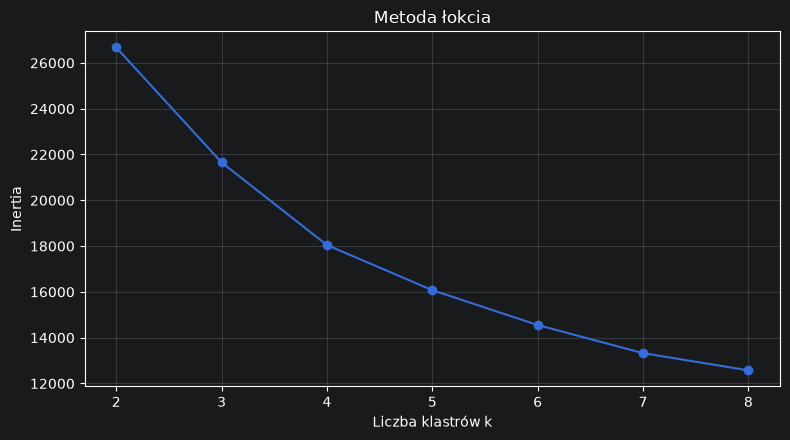

In [47]:

plt.figure(figsize=(8, 4.5))
plt.plot(
    k_evaluation["k"].to_list(),
    k_evaluation["inertia"].to_list(),
    marker="o",
)
plt.title("Metoda łokcia")
plt.xlabel("Liczba klastrów k")
plt.ylabel("Inertia")
plt.xticks(k_evaluation["k"].to_list())
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


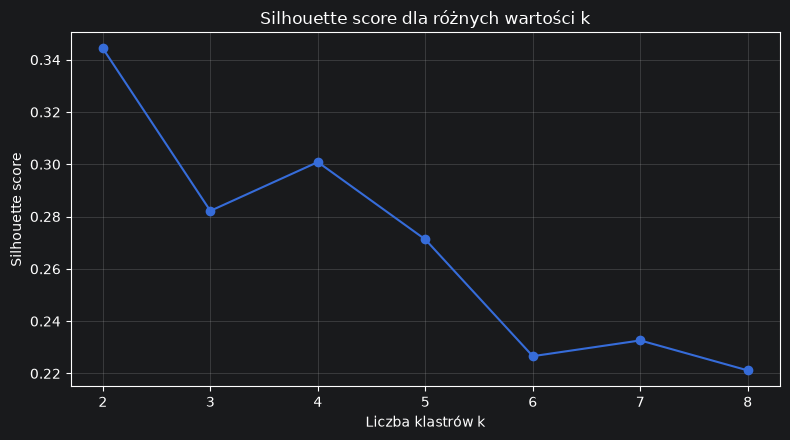

In [48]:

plt.figure(figsize=(8, 4.5))
plt.plot(
    k_evaluation["k"].to_list(),
    k_evaluation["silhouette_score"].to_list(),
    marker="o",
)
plt.title("Silhouette score dla różnych wartości k")
plt.xlabel("Liczba klastrów k")
plt.ylabel("Silhouette score")
plt.xticks(k_evaluation["k"].to_list())
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



### 17. Wybór `k` i finalny model K-Means

Notebook podpowiada wartość z najwyższym silhouette score. Przed prezentacją warto jednak ustawić `SELECTED_K` świadomie po obejrzeniu obu wykresów i profili biznesowych.

Większa liczba klastrów nie musi oznaczać lepszej segmentacji. Segmenty powinny być:

- wystarczająco różne,
- odpowiednio liczne,
- możliwe do opisania,
- przydatne do podjęcia działań.


In [49]:
recommended_k = int(
    k_evaluation
    .sort("silhouette_score", descending=True)
    .row(0, named=True)["k"]
)

# Możesz zmienić tę wartość po analizie wykresów.
SELECTED_K = recommended_k

print(f"Najwyższy silhouette score uzyskano dla k={recommended_k}.")
print(f"Finalny model zostanie uruchomiony dla k={SELECTED_K}.")


Najwyższy silhouette score uzyskano dla k=2.
Finalny model zostanie uruchomiony dla k=2.


In [50]:
kmeans = KMeans(
    n_clusters=SELECTED_K,
    init="k-means++",
    n_init=20,
    random_state=42,
)

kmeans_labels = kmeans.fit_predict(X_scaled)

customer_segments = customer_features.with_columns(
    pl.Series("cluster_id", kmeans_labels)
)

customer_segments.select(
    "customer_id",
    "cluster_id",
    *CLUSTER_FEATURES,
).head(10)


customer_id,cluster_id,recency_days,number_of_orders,total_revenue,average_order_value,number_of_products,purchase_frequency_30d,return_rate
str,i32,i64,u32,f64,f64,u32,f64,f64
"""12346""",0,326,12,77556.46,6463.038333,27,0.897756,0.291667
"""12347""",0,2,8,5633.32,704.165,126,0.595533,0.0
"""12348""",0,75,5,2019.4,403.88,25,0.413223,0.0
"""12349""",0,19,4,4428.69,1107.1725,138,0.210158,0.027778
"""12350""",1,310,1,334.4,334.4,17,30.0,0.0
"""12351""",1,375,1,300.93,300.93,21,30.0,0.0
"""12352""",0,36,10,2849.84,284.984,70,0.840336,0.088496
"""12353""",1,204,2,406.76,203.38,23,0.292683,0.0
"""12354""",1,232,1,1079.4,1079.4,58,30.0,0.0


### 18. Profile klastrów

Sam numer klastra niczego jeszcze nie wyjaśnia.

Dla każdego klastra obliczamy:

- liczbę i udział klientów,
- mediany najważniejszych cech.

Mediana jest tu przydatna, ponieważ profile klientów nadal mogą zawierać wartości ekstremalne.


In [51]:
profile_aggregations = [
    pl.len().alias("customers"),
    *[
        pl.col(column).median().round(3).alias(f"median_{column}")
        for column in CLUSTER_FEATURES
    ],
]

cluster_profiles = (
    customer_segments
    .group_by("cluster_id")
    .agg(profile_aggregations)
    .with_columns(
        (
            pl.col("customers") / customer_segments.height
        ).round(4).alias("customer_share")
    )
    .sort("cluster_id")
)

cluster_profiles


cluster_id,customers,median_recency_days,median_number_of_orders,median_total_revenue,median_average_order_value,median_number_of_products,median_purchase_frequency_30d,median_return_rate,customer_share
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64
0,3495,43.0,6.0,1842.14,328.38,84.0,0.51,0.008,0.5946
1,2383,380.0,1.0,297.99,202.15,17.0,30.0,0.0,0.4054


### 19. Profil względny

Poniższa tabela pokazuje średnie wartości **po skalowaniu**:

- wartość dodatnia - klaster znajduje się powyżej średniej zbioru,
- wartość ujemna - klaster znajduje się poniżej średniej,
- wartość bliska zeru - klaster jest zbliżony do przeciętnego klienta.

Dzięki temu łatwiej porównywać cechy o różnych jednostkach.


In [52]:
scaled_frame = pl.DataFrame(
    X_scaled,
    schema=CLUSTER_FEATURES,
    orient="row",
).with_columns(
    pl.Series("cluster_id", kmeans_labels)
)

relative_profiles = (
    scaled_frame
    .group_by("cluster_id")
    .agg(
        [
            pl.col(column).mean().round(3).alias(column)
            for column in CLUSTER_FEATURES
        ]
    )
    .sort("cluster_id")
)

relative_profiles


cluster_id,recency_days,number_of_orders,total_revenue,average_order_value,number_of_products,purchase_frequency_30d,return_rate
i32,f64,f64,f64,f64,f64,f64,f64
0,-0.435,0.572,0.605,0.293,0.565,-0.625,-0.021
1,0.637,-0.84,-0.887,-0.43,-0.829,0.917,0.03


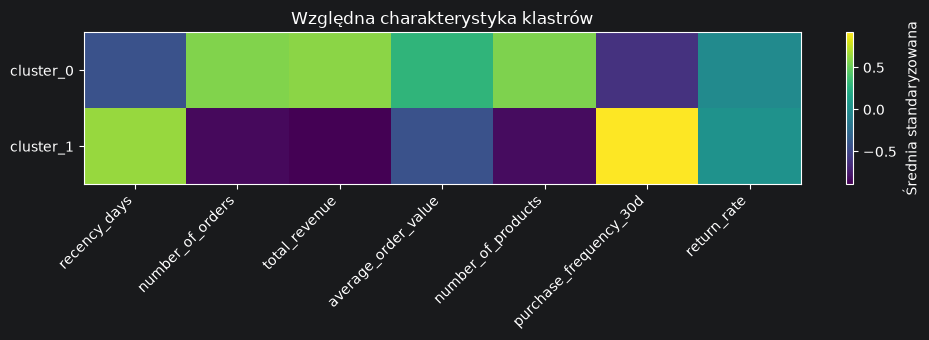

In [53]:
profile_matrix = relative_profiles.select(CLUSTER_FEATURES).to_numpy()
cluster_labels_for_plot = relative_profiles["cluster_id"].to_list()

plt.figure(figsize=(10, max(3.5, 0.8 * len(cluster_labels_for_plot))))
image = plt.imshow(profile_matrix, aspect="auto")
plt.colorbar(image, label="Średnia standaryzowana")
plt.xticks(
    range(len(CLUSTER_FEATURES)),
    CLUSTER_FEATURES,
    rotation=45,
    ha="right",
)
plt.yticks(
    range(len(cluster_labels_for_plot)),
    [f"cluster_{cluster_id}" for cluster_id in cluster_labels_for_plot],
)
plt.title("Względna charakterystyka klastrów")
plt.tight_layout()
plt.show()


### 20. Nadawanie nazw segmentom

K-Means zwraca techniczne identyfikatory:

```text
cluster_0
cluster_1
cluster_2
```

Numery nie mają stałego znaczenia i przy innym uczeniu mogą zostać zamienione miejscami.

Analityk powinien na podstawie profili nadać segmentom nazwy biznesowe, np.:

- klienci okazjonalni,
- klienci regularni,
- klienci wysokowartościowi,
- klienci traceni,
- klienci hurtowi.

Nazwy poniżej należy uzupełnić **dopiero po analizie otrzymanych profili**.


In [54]:
# Przykład po ręcznej interpretacji wyników:
#
# CLUSTER_NAMES = {
#     0: "Klienci okazjonalni",
#     1: "Klienci wysokowartościowi",
#     2: "Klienci traceni",
#     3: "Klienci regularni",
# }

CLUSTER_NAMES = {
    cluster_id: f"Segment {cluster_id} — do interpretacji"
    for cluster_id in customer_segments["cluster_id"].unique().sort().to_list()
}

customer_segments = customer_segments.with_columns(
    pl.col("cluster_id")
    .replace_strict(CLUSTER_NAMES)
    .alias("segment_name")
)

customer_segments.select(
    "customer_id",
    "cluster_id",
    "segment_name",
    "recency_days",
    "number_of_orders",
    "total_revenue",
).head(10)


customer_id,cluster_id,segment_name,recency_days,number_of_orders,total_revenue
str,i32,str,i64,u32,f64
"""12346""",0,"""Segment 0 — do interpretacji""",326,12,77556.46
"""12347""",0,"""Segment 0 — do interpretacji""",2,8,5633.32
"""12348""",0,"""Segment 0 — do interpretacji""",75,5,2019.4
"""12349""",0,"""Segment 0 — do interpretacji""",19,4,4428.69
"""12350""",1,"""Segment 1 — do interpretacji""",310,1,334.4
"""12351""",1,"""Segment 1 — do interpretacji""",375,1,300.93
"""12352""",0,"""Segment 0 — do interpretacji""",36,10,2849.84
"""12353""",1,"""Segment 1 — do interpretacji""",204,2,406.76
"""12354""",1,"""Segment 1 — do interpretacji""",232,1,1079.4


### 21. DBSCAN

`eps` określa promień sąsiedztwa w przestrzeni przeskalowanych cech.  
Dla kilku wartości sprawdzamy:

- liczbę znalezionych klastrów,
- udział rekordów oznaczonych jako szum,
- silhouette score liczony tylko dla rekordów przypisanych do zwykłych klastrów.


In [55]:
DBSCAN_MIN_SAMPLES = 10 if n_customers >= 100 else 3
EPS_CANDIDATES = [0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]

dbscan_results: list[dict[str, float | int | None]] = []

for eps in EPS_CANDIDATES:
    labels = DBSCAN(
        eps=eps,
        min_samples=DBSCAN_MIN_SAMPLES,
    ).fit_predict(X_scaled)

    cluster_ids = set(labels)
    n_clusters = len(cluster_ids - {-1})
    noise_share = float(np.mean(labels == -1))

    non_noise_mask = labels != -1
    non_noise_labels = labels[non_noise_mask]
    non_noise_clusters = set(non_noise_labels)

    score: float | None = None
    if (
        len(non_noise_clusters) >= 2
        and non_noise_mask.sum() > len(non_noise_clusters)
    ):
        score = float(
            silhouette_score(
                X_scaled[non_noise_mask],
                non_noise_labels,
                sample_size=min(5_000, int(non_noise_mask.sum())),
                random_state=42,
            )
        )

    dbscan_results.append(
        {
            "eps": eps,
            "min_samples": DBSCAN_MIN_SAMPLES,
            "clusters": n_clusters,
            "noise_share": noise_share,
            "silhouette_without_noise": score,
        }
    )

dbscan_evaluation = pl.DataFrame(dbscan_results)
dbscan_evaluation


eps,min_samples,clusters,noise_share,silhouette_without_noise
f64,i64,i64,f64,f64
0.4,10,13,0.601735,-0.154848
0.6,10,4,0.234774,0.140303
0.8,10,2,0.102416,0.402507
1.0,10,1,0.056822,null
1.2,10,2,0.030623,0.605821
1.5,10,2,0.018033,0.596843
2.0,10,2,0.005614,0.679397


### 22. Finalny DBSCAN

Automatyczna podpowiedź wybiera spośród rozsądnych kandydatów konfigurację z najwyższym silhouette score. Jest to tylko punkt startowy — interpretacja liczby grup i udziału szumu nadal należy do analityka.


In [56]:
valid_dbscan_candidates = dbscan_evaluation.filter(
    (pl.col("clusters") >= 2)
    & (pl.col("clusters") <= 10)
    & (pl.col("noise_share") <= 0.60)
    & pl.col("silhouette_without_noise").is_not_null()
)

if valid_dbscan_candidates.height > 0:
    DBSCAN_EPS = float(
        valid_dbscan_candidates
        .sort("silhouette_without_noise", descending=True)
        .row(0, named=True)["eps"]
    )
else:
    DBSCAN_EPS = 1.0

print(
    f"Wybrane parametry: eps={DBSCAN_EPS}, "
    f"min_samples={DBSCAN_MIN_SAMPLES}"
)


Wybrane parametry: eps=2.0, min_samples=10


In [57]:
dbscan = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES,
)

dbscan_labels = dbscan.fit_predict(X_scaled)

customer_segments = customer_segments.with_columns(
    pl.Series("dbscan_cluster_id", dbscan_labels),
    pl.Series("dbscan_is_noise", dbscan_labels == -1),
)

dbscan_summary = (
    customer_segments
    .group_by("dbscan_cluster_id")
    .agg(
        pl.len().alias("customers"),
        pl.col("total_revenue").median().round(2).alias("median_total_revenue"),
        pl.col("number_of_orders").median().round(2).alias("median_orders"),
        pl.col("recency_days").median().round(2).alias("median_recency_days"),
    )
    .with_columns(
        (
            pl.col("customers") / customer_segments.height
        ).round(4).alias("customer_share")
    )
    .sort("dbscan_cluster_id")
)

dbscan_summary


dbscan_cluster_id,customers,median_total_revenue,median_orders,median_recency_days,customer_share
i64,u32,f64,f64,f64,f64
-1,33,6001.49,3.0,235.0,0.0056
0,5835,893.78,3.0,95.0,0.9927
1,10,537.7,1.0,438.0,0.0017


In [58]:
comparison = pl.DataFrame(
    {
        "method": ["K-Means", "DBSCAN"],
        "regular_clusters": [
            customer_segments["cluster_id"].n_unique(),
            len(set(dbscan_labels) - {-1}),
        ],
        "customers_marked_as_noise": [
            0,
            int(np.sum(dbscan_labels == -1)),
        ],
        "noise_share": [
            0.0,
            float(np.mean(dbscan_labels == -1)),
        ],
    }
)

comparison


method,regular_clusters,customers_marked_as_noise,noise_share
str,i64,i64,f64
"""K-Means""",2,0,0.0
"""DBSCAN""",2,33,0.005614


## 23. Interpretacja porównania

### K-Means

Najczęściej lepiej pasuje do klasycznej segmentacji biznesowej, gdy:

- chcemy przypisać każdego klienta do jednej grupy,
- potrzebujemy stabilnej i łatwej do komunikacji liczby segmentów,
- grupy mają być później wykorzystywane w raportach lub kampaniach.

### DBSCAN

Jest interesujący, gdy:

- spodziewamy się nieregularnych skupisk,
- nie znamy liczby grup,
- rekordy niepasujące do żadnego gęstego obszaru są ważnym wynikiem,
- chcemy znaleźć lokalne skupiska albo potencjalne anomalie.

W danych klientów o kilku cechach DBSCAN może oznaczyć wielu klientów jako szum. Nie musi to oznaczać błędu algorytmu - może wskazywać, że przy danej definicji odległości dane nie tworzą wyraźnych obszarów o podobnej gęstości.



## 24. Zapis wyników segmentacji

Zapisujemy tabelę klientów wraz z identyfikatorami K-Means i DBSCAN.  
Plik może zostać później wykorzystany w PCA, analizie anomalii oraz aplikacji Streamlit.


In [59]:

SEGMENTS_PATH = OUTPUT_DIR / "online_retail_customer_segments.parquet"
customer_segments.write_parquet(SEGMENTS_PATH)

print(
    f"Zapisano segmentację {customer_segments.height:,} klientów do: "
    f"{SEGMENTS_PATH}"
)


Zapisano segmentację 5,878 klientów do: outputs/online_retail_customer_segments.parquet


## Redukcja wymiarów za pomocą PCA

Cel:

> zredukować wielowymiarowy profil klienta do dwóch komponentów i przedstawić segmenty K-Means na wykresie.

Przepływ:

```text
cechy klientów
→ transformacja log1p
→ StandardScaler
→ PCA(n_components=2)
→ wykres segmentów
```

PCA nie wybiera dwóch istniejących kolumn. Tworzy dwie nowe zmienne będące kombinacjami cech wejściowych.


### 25. Przygotowanie danych do PCA

Korzystamy dokładnie z tej samej przeskalowanej macierzy `X_scaled`, na której wcześniej uruchomiliśmy K-Means. Dzięki temu wizualizacja pokazuje tę samą reprezentację klientów, która była podstawą segmentacji.


In [60]:
from sklearn.decomposition import PCA

try:
    X_scaled
    customer_segments
except NameError as exc:
    raise RuntimeError(
        "Najpierw wykonaj część 2 notebooka z przygotowaniem X_scaled "
        "i segmentacją K-Means."
    ) from exc

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Kształt przed PCA:", X_scaled.shape)
print("Kształt po PCA:", X_pca_2d.shape)


Kształt przed PCA: (5878, 7)
Kształt po PCA: (5878, 2)


### 26. Explained variance

`explained_variance_ratio_` pokazuje, jaka część zmienności danych jest reprezentowana przez każdy komponent.

Jeżeli dwa komponenty wyjaśniają np. 65% wariancji, oznacza to, że wykres 2D zachowuje dużą, ale niepełną część informacji zawartej w oryginalnych cechach.


In [61]:
explained_variance = pl.DataFrame(
    {
        "component": ["PC1", "PC2"],
        "explained_variance_ratio": pca_2d.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(
            pca_2d.explained_variance_ratio_
        ),
    }
)

explained_variance

component,explained_variance_ratio,cumulative_explained_variance
str,f64,f64
"""PC1""",0.515026,0.515026
"""PC2""",0.154817,0.669843


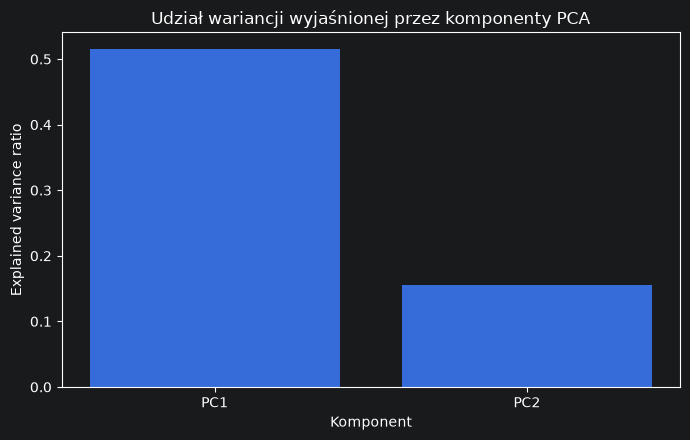

In [62]:
plt.figure(figsize=(7, 4.5))
plt.bar(
    explained_variance["component"].to_list(),
    explained_variance["explained_variance_ratio"].to_list(),
)
plt.title("Udział wariancji wyjaśnionej przez komponenty PCA")
plt.xlabel("Komponent")
plt.ylabel("Explained variance ratio")
plt.tight_layout()
plt.show()


### 27. Wizualizacja segmentów klientów

Punkty blisko siebie mają podobne profile w wielowymiarowej przestrzeni cech. Kolor grupy nie jest tu ustawiany ręcznie — wykres używa domyślnej mapy Matplotlib na podstawie `cluster_id`.

Pamiętajmy, że jest to projekcja. Nakładanie się punktów na wykresie 2D nie musi oznaczać, że klastry są identyczne w pełnej przestrzeni.


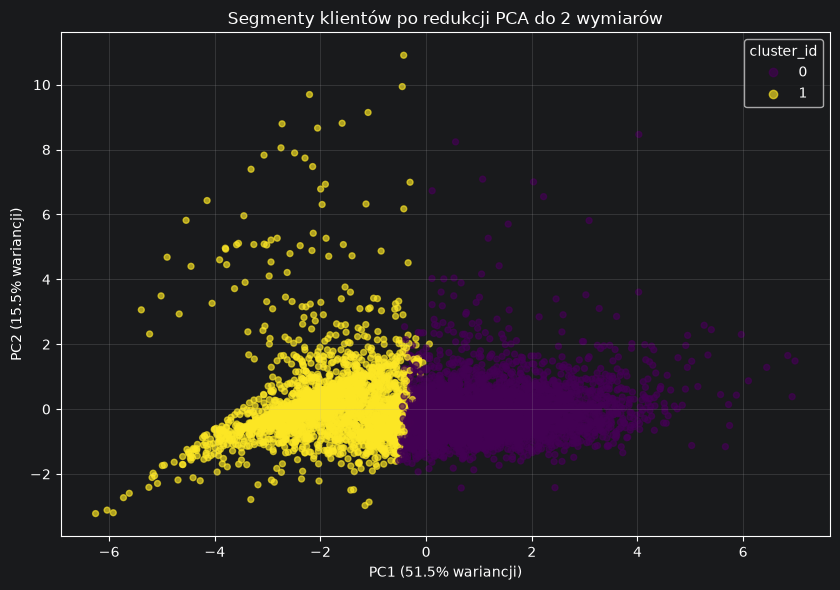

In [63]:
pca_plot_frame = customer_segments.select(
    "customer_id",
    "cluster_id",
).with_columns(
    pl.Series("PC1", X_pca_2d[:, 0]),
    pl.Series("PC2", X_pca_2d[:, 1]),
)

plt.figure(figsize=(8.5, 6))
scatter = plt.scatter(
    pca_plot_frame["PC1"].to_numpy(),
    pca_plot_frame["PC2"].to_numpy(),
    c=pca_plot_frame["cluster_id"].to_numpy(),
    s=18,
    alpha=0.65,
)
plt.title("Segmenty klientów po redukcji PCA do 2 wymiarów")
plt.xlabel(
    f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} wariancji)"
)
plt.ylabel(
    f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} wariancji)"
)
legend = plt.legend(
    *scatter.legend_elements(),
    title="cluster_id",
    loc="best",
)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


### 28. Jak powstają komponenty?

Każdy komponent jest kombinacją liniową wszystkich cech wejściowych. Współczynniki nazywamy często `loadings`.

Duża dodatnia lub ujemna wartość oznacza, że dana cecha silniej wpływa na kierunek komponentu. Znak sam w sobie jest umowny — cały komponent można odwrócić bez zmiany informacji.


In [64]:

pca_loadings = pl.DataFrame(
    {
        "feature": CLUSTER_FEATURES,
        "PC1_loading": pca_2d.components_[0],
        "PC2_loading": pca_2d.components_[1],
    }
).with_columns(
    (
        pl.col("PC1_loading").abs()
        + pl.col("PC2_loading").abs()
    ).alias("combined_absolute_loading")
).sort(
    "combined_absolute_loading",
    descending=True,
)

pca_loadings


feature,PC1_loading,PC2_loading,combined_absolute_loading
str,f64,f64,f64
"""average_order_value""",0.286638,0.535343,0.821981
"""return_rate""",-0.015275,0.746068,0.761342
"""total_revenue""",0.500432,0.204013,0.704444
"""recency_days""",-0.345835,0.238334,0.584169
"""purchase_frequency_30d""",-0.368299,0.197926,0.566226
"""number_of_orders""",0.461899,-0.095389,0.557288
"""number_of_products""",0.445619,-0.100462,0.546081


## Nietypowi klienci względem segmentów

K-Means może służyć nie tylko do segmentacji. Dla każdego klienta możemy obliczyć odległość od centroidu klastra, do którego został przypisany.

Klient bardzo oddalony od centrum swojego segmentu może:

- łączyć nietypowe cechy,
- być przypadkiem granicznym między segmentami,
- reprezentować klienta hurtowego lub wyjątkowo aktywnego,
- zawierać błąd albo wymagać ręcznej weryfikacji.

Jest to **heurystyka anomalii względem segmentów**, a nie uniwersalna definicja anomalii.


In [65]:

distances_to_centroids = kmeans.transform(X_scaled)
assigned_centroid_distance = distances_to_centroids[
    np.arange(len(kmeans_labels)),
    kmeans_labels,
]

CENTROID_ANOMALY_QUANTILE = 0.99
centroid_distance_threshold = float(
    np.quantile(
        assigned_centroid_distance,
        CENTROID_ANOMALY_QUANTILE,
    )
)

customer_segments = customer_segments.with_columns(
    pl.Series(
        "centroid_distance",
        assigned_centroid_distance,
    ),
    pl.Series(
        "is_centroid_anomaly",
        assigned_centroid_distance >= centroid_distance_threshold,
    ),
)

print(
    "Próg odległości:",
    round(centroid_distance_threshold, 3),
)
print(
    "Klienci oznaczeni jako nietypowi:",
    customer_segments["is_centroid_anomaly"].sum(),
)


Próg odległości: 6.334
Klienci oznaczeni jako nietypowi: 59


In [66]:
customer_segments.filter(
    pl.col("is_centroid_anomaly")
).select(
    "customer_id",
    "cluster_id",
    "centroid_distance",
    "recency_days",
    "number_of_orders",
    "total_revenue",
    "average_order_value",
    "number_of_products",
    "purchase_frequency_30d",
    "return_rate",
    "dbscan_cluster_id",
    "dbscan_is_noise",
).sort(
    "centroid_distance",
    descending=True,
).head(15)


customer_id,cluster_id,centroid_distance,recency_days,number_of_orders,total_revenue,average_order_value,number_of_products,purchase_frequency_30d,return_rate,dbscan_cluster_id,dbscan_is_noise
str,i32,f64,i64,u32,f64,f64,u32,f64,f64,i64,bool
"""12918""",1,11.207168,626,1,10953.5,10953.5,1,30.0,0.666667,-1,true
"""14255""",1,10.886251,546,1,1000.63,1000.63,1,30.0,0.75,1,false
"""13776""",1,10.693443,428,2,623.98,311.99,1,60.0,0.75,1,false
"""16446""",0,10.324713,1,2,168472.5,84236.25,3,0.292683,0.4,-1,true
"""15760""",1,10.20477,631,2,13916.34,6958.17,1,60.0,0.6,-1,true
…,…,…,…,…,…,…,…,…,…,…,…
"""14328""",1,9.499607,438,1,445.05,445.05,1,30.0,0.666667,1,false
"""15802""",1,9.498329,143,1,451.42,451.42,1,30.0,0.666667,1,false
"""14832""",1,9.467904,630,1,322.69,322.69,1,30.0,0.666667,1,false
